In [18]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(7) 

# Funções auxiliares

In [ ]:
def neuron(u, params):
    """Single neuron with step activation function"""
    # Linear combination
    x = u.dot(params)
    # Activation function: step function
    y = np.where(x > 0, 1, 0)
    return y

def calculate_residual(X_i, theta, y_i):
    prediction = neuron(X_i, theta)
    residual = prediction - y_i
    return residual

def gradient_descent(X, y, initial_theta, learning_rate, n_epochs):
    theta_current = initial_theta.copy()
    errors = np.zeros((n_epochs, 1))
    
    for epoch in range(n_epochs):
        total_squared_error = 0.0

        for i in range(len(X)):
            # Calculate error for current data point
            residual = calculate_residual(X[[i], :], theta_current, y[i])
            
            # Update parameters: θ = θ - α * 2 * e * Xᵀ
            gradient = 2 * residual * X[[i], :].T
            theta_current = theta_current - (learning_rate * gradient)
            
            total_squared_error += residual**2

        errors[epoch] = total_squared_error
        
        # Early stopping if error is zero
        if total_squared_error == 0:
            print(f"✅ Converged at epoch {epoch}!")
            errors = errors[:epoch+1]
            break
    
    print("Optimized parameters:", theta_current.flatten())    
    return theta_current, errors


def calculate_accuracy(y_pred, y_real):
    """Calculate model accuracy"""
    return np.mean(y_pred.flatten() == y_real) * 100

In [20]:
dados = np.zeros((5,3,10)) # Matriz para guardar os numeros

# Numero 0
dados[:,:,0] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 1
dados[:,:,1] = [[0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0]]
# Numero 2
dados[:,:,2] = [[1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [1.0, 0.0, 0.0],
                [1.0, 1.0, 1.0]]
# Numero 3
dados[:,:,3] = [[1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 4
dados[:,:,4] = [[1.0, 0.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 0.0, 1.0]]
# Numero 5
dados[:,:,5] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 0.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 6
dados[:,:,6] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 0.0],
                [1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 7
dados[:,:,7] = [[1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 0.0, 1.0]]
# Numero 8
dados[:,:,8] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 9
dados[:,:,9] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 0.0, 1.0]]

In [ ]:
# Organiza matriz + coluna bias e chutes inicias
U = np.zeros((10,15)) #Guardar os valores
for i in range(10):
  U[i,:] = dados[:,:,1].flatten()
  # Adicionando as colunas de 1's

X = np.hstack((U,np.ones((10,1))))

#Vetor de saida par = 0 e impar = 1 classificação
y = np.array([0, 0, 0, 1, 0, 0, 1, 0, 0, 1]).reshape(-1, 1) # forçar vetor coluna

print("Dataset prepared:")
print(f"X shape: {X.shape}")  # Should be (10, 16)
print(f"y shape: {y.shape}")  # Should be (10, 1)
print(f"Target values: {y.flatten()}")


# Chute iniciais dos parâmetros
theta_0 = np.random.randn(16, 1) * 0.1
theta_0[-1] = 0  # Bias inicial zero



Dataset prepared:
X shape: (10, 16)
y shape: (10, 1)
Target values: [0 0 0 1 0 0 1 0 0 1]


[[ 0.05545803]
 [-0.02761191]
 [ 0.02744599]
 [-0.15265245]
 [ 0.12506997]
 [ 0.01543355]
 [-0.03871399]
 [ 0.16290722]
 [-0.0045386 ]
 [-0.14506787]
 [-0.08052279]
 [-0.22883151]
 [ 0.10493965]
 [-0.08164743]
 [-0.07425535]
 [-0.04      ]]


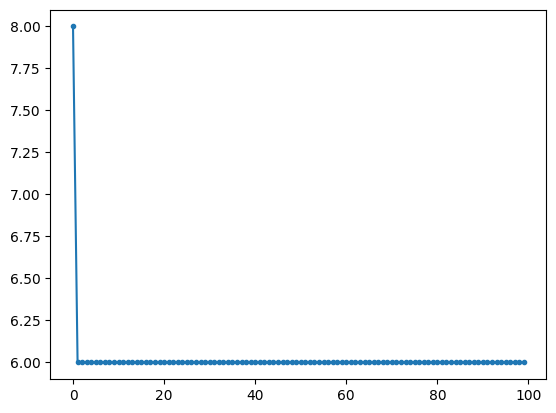

In [ ]:
theta_j = theta_0.copy()
alpha = 1e-2 # Taxa de aprendizagem
n_epocas = 100
E = np.zeros((n_epocas,1))
n_dados = X.shape[0] # Número de dados da matriz de entrada (numero de dados)
for i in range(n_epocas):
  Soma = 0.0
  for j in range(n_dados):
    # Calcular o erro
    e_j = (neuron(UI[[j],:],theta_j) - y[j])
    # Atualização do theta_j
    theta_j = theta_j - alpha*2*e_j*X[[j],:].T
    # Guardando o Erro
    Soma = Soma + e_j**2
  # end for
  E[i] = Soma
#end for
print(theta_j)
plt.plot(E,'.-')

In [ ]:
   n  


Initial prediction: [1 1 1 1 1 1 1 1 1 1]
Initial accuracy: 30.0%
Optimized parameters: [ 0.05545803  0.01238809  0.02744599 -0.15265245  0.16506997  0.01543355
 -0.03871399  0.20290722 -0.0045386  -0.14506787 -0.04052279 -0.22883151
  0.10493965 -0.04164743 -0.07425535  0.        ]

Initial prediction: [1 1 1 1 1 1 1 1 1 1]
Initial accuracy: 30.0%
